In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SKILL_LAB/loan_data.csv')
X = df.drop(columns=['id', 'loan_paid_back'])
y = df['loan_paid_back']

In [9]:
numerical_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score',
                  'loan_amount', 'interest_rate']
categorical_cols = ['gender', 'marital_status', 'education_level',
                    'employment_status', 'loan_purpose', 'grade_subgrade']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ada_model)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['annual_income',
                                                   'debt_to_income_ratio',
                                                   'credit_score',
                                                   'loan_amount',
                                                   'interest_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'marital_status',
                                                   'education_level',
                                                   'employment_status',
                                                   'loan_purpose',
                                                   'grade_subgrade'])])),
                ('classifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                     random_state=42),
                                    learning_rate=0.5, n_estimators=200,
                                    random_state=42))])

In [11]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.9131


In [12]:
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_proba'] = y_proba
test_df = test_df.reset_index(drop=True)

In [14]:
print("\nAUC by Loan Purpose")
purpose_aucs = {}
for purpose in test_df['loan_purpose'].dropna().unique():
    subset = test_df[test_df['loan_purpose'] == purpose]
    if len(subset['y_true'].unique()) < 2:
        continue
    auc = roc_auc_score(subset['y_true'], subset['y_proba'])
    purpose_aucs[purpose] = (auc, len(subset))
sorted_purposes = sorted(purpose_aucs.items(), key=lambda x: x[1][0])

print("\ntop 3 performing purposes:")
for purpose, (auc, n) in sorted_purposes[-3:][::-1]:
    print(f"{purpose}: AUC = {auc:.4f} (n={n})")

print("\nbottom 3 performing purposes:")
for purpose, (auc, n) in sorted_purposes[:3]:
    print(f"{purpose}: AUC = {auc:.4f} (n={n})")


AUC by Loan Purpose

top 3 performing purposes:
Education: AUC = 0.9233 (n=3202)
Medical: AUC = 0.9214 (n=2088)
Vacation: AUC = 0.9171 (n=760)

bottom 3 performing purposes:
Car: AUC = 0.9031 (n=5353)
Business: AUC = 0.9117 (n=3091)
Debt consolidation: AUC = 0.9126 (n=29317)


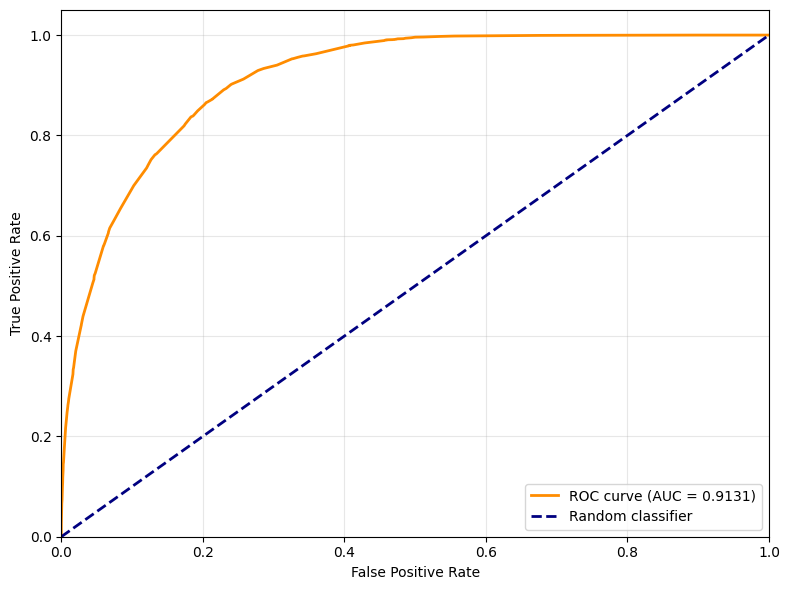

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()